<a href="https://colab.research.google.com/github/aaronbui99/neural-network/blob/main/Breast_Cancer_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_breast_histopathology_images_path = kagglehub.dataset_download('paultimothymooney/breast-histopathology-images')

print('Data source import complete.')


Data source import complete.


**Import libraries**

In [2]:
!pip install opencv-python


In [3]:
import os
import glob
import random
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import cv2
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


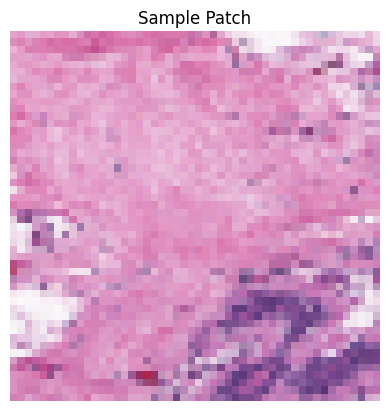

In [4]:
import cv2
import matplotlib.pyplot as plt

# Example path to a sample image (adjust based on your walk output)
sample_image_path = '/kaggle/input/breast-histopathology-images/10253/0/10253_idx5_x1001_y1001_class0.png'

img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Patch")
plt.axis('off')
plt.show()


In [5]:
import glob
import random

# Get all image paths
all_image_paths = glob.glob('/kaggle/input/breast-histopathology-images/*/*/*.png')


# Assign label from filename (1 if _1_ is in name)
data = [(path, 1 if '1' in os.path.basename(path) else 0) for path in all_image_paths]

# Downsample to a balanced set (e.g., 2000 from each class)
class_0 = [d for d in data if d[1] == 0]
class_1 = [d for d in data if d[1] == 1]
print(f"Class 0 count: {len(class_0)}")
print(f"Class 1 count: {len(class_1)}")

Class 0 count: 0
Class 1 count: 277524


**Created A Balanced Dataset for testing**

In [6]:
import glob
import random

# Get all image paths
all_image_paths = glob.glob('/kaggle/input/breast-histopathology-images/*/*/*.png')

# Assign label from filename (1 if _1_ is in name)
data = [(path, int(os.path.basename(os.path.dirname(path)))) for path in all_image_paths]

# Separate by class
class_0 = [d for d in data if d[1] == 0]
class_1 = [d for d in data if d[1] == 1]

print(f"Class 0 count: {len(class_0)}")
print(f"Class 1 count: {len(class_1)}")

min_samples = min(len(class_0), len(class_1), 10000)
sampled_data = random.sample(class_0, min_samples) + random.sample(class_1, min_samples)
random.shuffle(sampled_data)

# Split into train and val
train_data, val_data = train_test_split(sampled_data, test_size=0.2, stratify=[x[1] for x in sampled_data])

#print(f"sampled_data: {sampled_data}")

Class 0 count: 198738
Class 1 count: 78786


**Prepare for Training**

In [7]:
X = []
y = []

for path, label in sampled_data:
    img = cv2.imread(path)
    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

print(X)
print(y)

[[[[0.7372549  0.65098039 0.90980392]
   [0.76862745 0.68627451 0.91764706]
   [0.75686275 0.67843137 0.91764706]
   ...
   [0.84313725 0.79215686 0.9372549 ]
   [0.81960784 0.75686275 0.92941176]
   [0.78431373 0.70588235 0.91764706]]

  [[0.75294118 0.66666667 0.90588235]
   [0.77254902 0.69411765 0.91372549]
   [0.77647059 0.70196078 0.91372549]
   ...
   [0.82745098 0.76862745 0.92941176]
   [0.8        0.7254902  0.92156863]
   [0.76078431 0.67843137 0.91764706]]

  [[0.75686275 0.67058824 0.90980392]
   [0.77254902 0.69019608 0.91764706]
   [0.78431373 0.71372549 0.91764706]
   ...
   [0.79607843 0.7254902  0.91764706]
   [0.77254902 0.69411765 0.90980392]
   [0.76470588 0.69411765 0.91372549]]

  ...

  [[0.8        0.72156863 0.9254902 ]
   [0.81568627 0.74901961 0.9254902 ]
   [0.80784314 0.74509804 0.92156863]
   ...
   [0.79215686 0.72156863 0.92156863]
   [0.8        0.72941176 0.9254902 ]
   [0.8        0.7254902  0.9254902 ]]

  [[0.80784314 0.72941176 0.9254902 ]
   [0.8

**Define Dataset Class**

In [8]:
class HistopathologyDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        image = Image.open(path).convert('RGB')
        image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)


print(f"Define success")

Define success


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_dataset = HistopathologyDataset(train_data, train_transform)
val_dataset = HistopathologyDataset(val_data, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


print(f"Train dataset: {train_dataset}")
print(f"Val dataset: {val_dataset}")

print(f"Train loader: {train_loader}")
print(f"Val loader: {val_loader}")

Train dataset: <__main__.HistopathologyDataset object at 0x7a0a782f1910>
Val dataset: <__main__.HistopathologyDataset object at 0x7a0a782f18d0>
Train loader: <torch.utils.data.dataloader.DataLoader object at 0x7a0a782f1b10>
Val loader: <torch.utils.data.dataloader.DataLoader object at 0x7a0a7a9345d0>


**Define a CNN Model**

In [10]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 64x64 → 64x64
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # → 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # → 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # → 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # → 8x8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)  # raw logit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.view(-1)  # Ensure shape [batch_size]


**Train model**

In [ ]:
from sklearn.metrics import classification_report

EPOCHS = 150
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

# --- Choose optimizer ---
# Option 1: SGD with momentum
# optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)

# Option 2: AdamW (recommended for large data)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Loss function
criterion = torch.nn.BCEWithLogitsLoss()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Tracking
        running_loss += loss.item() * images.size(0)  # sum loss for batch
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    avg_loss = running_loss / total
    train_accuracy = correct / total
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")

    # ---------------- Evaluation ----------------
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float().cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    # Classification report
    report = classification_report(y_true, y_pred, digits=4)
    print(f"Validation metrics for Epoch {epoch+1}:\n{report}")


Epoch 1, Loss: 0.6249, Train Accuracy: 0.7634
Validation metrics for Epoch 1:
              precision    recall  f1-score   support

         0.0     0.7947    0.7995    0.7971      2000
         1.0     0.7983    0.7935    0.7959      2000

    accuracy                         0.7965      4000
   macro avg     0.7965    0.7965    0.7965      4000
weighted avg     0.7965    0.7965    0.7965      4000

